# **SPECTRA-CQ Phase 4: Physics-Informed Topologies and Final Convergence (MSE)**
This notebook executes Part 2 of the 6-sensor spatial fusion ablation study.
We have established baselines for Classical CAE, HQAE-None and HQAE-Strong in Notebook 07a. We will now train the domain-specific Variational Quantum Circuits:
* Bridge Graph (Hard) topology
* Bridge Graph (Soft) topology

These architectures inject the macroscopic geometry of the openLAB bridge directly into the quantum entanglement layout. Following execution, this notebook aggregates the saved logs from all 5 experiments to generate the definitive Phase 4 Validation MSE comparison.

*Note: Optimized weights are saved directly to Google Drive at each improving epoch to protect against Colab runtime disconnections.*

*Note: Run this training file on T4 GPU runtime on Colab*

In [1]:
from google.colab import drive
import os
import sys

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (292/292), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 365 (delta 133), reused 242 (delta 84), pack-reused 73 (from 1)
Receiving objects: 100% (365/365), 36.13 MiB | 38.95 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 133.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25

In [2]:
# Hardware Verification
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


*NOTE: The 13.97 GB dataset of multi-sensor matrices must be extracted from the Google Drive network mount directly to the Colab instance's local high-speed NVMe disk to prevent I/O starvation and GPU bottlenecking during training.*

*Automatically aligned the nested path created by the Linux zip utility to match the YAML configuration expectations.*

In [3]:
import sys
import glob

sys.path.append(os.path.abspath('.'))

# Transfer multi-channel dataset to local NVMe
DRIVE_ARCHIVE_PATH = "/content/drive/MyDrive/spectra-cq-data/spectra_matrices_6ch.zip"
LOCAL_DATA_DIR = "/content/local_spectra_data"
EXPECTED_DIR = f"{LOCAL_DATA_DIR}/processed_spectrograms_6ch"

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
print("Extracting multi-sensor tensors to local NVMe. This may take a few minutes..")
!unzip -q {DRIVE_ARCHIVE_PATH} -d {LOCAL_DATA_DIR}

# Align the directory structure if the Linux zip nested the folders
extracted_files = glob.glob(f"{LOCAL_DATA_DIR}/**/*.npy", recursive=True)
if extracted_files:
    actual_dir = os.path.dirname(extracted_files[0])
    if actual_dir != EXPECTED_DIR:
        print(f"Aligning nested directory structure from {actual_dir} to {EXPECTED_DIR}..")
        os.makedirs(EXPECTED_DIR, exist_ok=True)
        !mv {actual_dir}/* {EXPECTED_DIR}/
        !rm -rf {LOCAL_DATA_DIR}/content

print("Extraction and path alignment complete. Ready for training loops.")

Extracting multi-sensor tensors to local NVMe. This may take a few minutes..
Aligning nested directory structure from /content/local_spectra_data/content/processed_spectrograms_6ch to /content/local_spectra_data/processed_spectrograms_6ch..
Extraction and path alignment complete. Ready for training loops.


## **Experiment 4: HQAE : Physics-Informed Bridge Graph (`hard`)**
Here, we evaluate geometric attenuation using strict spatial cutoffs.

This custom topology bounds the quantum entanglement to the physical reality of the openLAB bridge. CNOT gates are mathematically forbidden between sensor nodes separated by a Euclidean distance greater than 15.0 meters.

This tests if forcing the quantum circuit to respect localized stress-wave propagation improves the optimization landscape.

In [ ]:
!python -u scripts/run_experiment.py --config configs/ablation_hqae_bridge_hard.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4_bridge_hard.log

2026-07-02 13:08:03,042 - INFO - Compute device allocated: cuda
2026-07-02 13:08:03,042 - INFO - Starting Protocol Run | Seed: 42
2026-07-02 13:08:03,046 - INFO - System locked to deterministic seed: 42
2026-07-02 13:08:04,002 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)..
2026-07-02 13:08:10,398 - INFO - Initiating training on cuda for 15 epochs.
2026-07-02 13:11:46,597 - INFO - Epoch 1/15 | Train MSE: 0.092651 | Val MSE: 0.027381 | LR: 1.00e-03
2026-07-02 13:11:46,964 - INFO - New optimal weights saved. Validation Loss: 0.027381
2026-07-02 13:15:16,272 - INFO - Epoch 2/15 | Train MSE: 0.021067 | Val MSE: 0.018985 | LR: 1.00e-03
2026-07-02 13:15:16,303 - INFO - New optimal weights saved. Validation Loss: 0.018985
2026-07-02 13:18:46,286 - INFO - Epoch 3/15 | Train MSE: 0.018771 | Val MSE: 0.018455 | LR: 1.00e-03
2026-07-02 13:18:46,315 - INFO - New optimal weights saved. Validation Loss: 0.018455
2026-07-02 13:22:17,291 - INFO - Epoch 4/15 | Train MSE: 0.018540 | Val MSE: 

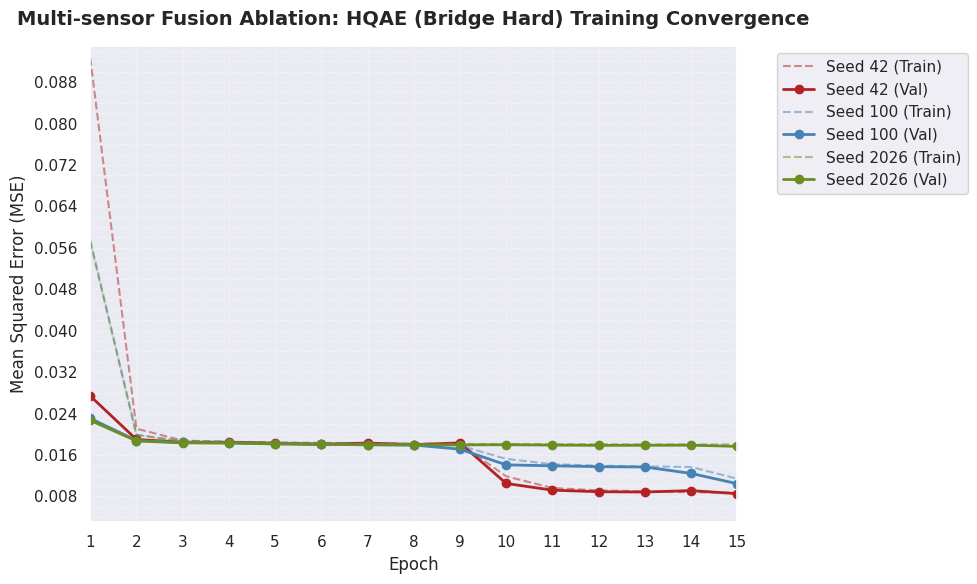

In [ ]:
from src.utils.viz import plot_training_logs

DRIVE_LOGS = "/content/drive/MyDrive/spectra-cq-data/logs"
Y_LIMITS = (0.003, 0.095)

plot_training_logs(f"{DRIVE_LOGS}/phase4_bridge_hard.log", title="Multi-sensor Fusion Ablation: HQAE (Bridge Hard) Training Convergence", y_lim=Y_LIMITS)

## **Experiment 5: HQAE : Physics-Informed Bridge Graph (`soft`)**
Now, evaluate geometric attenuation using parameterized exponential scaling.

Instead of a strict distance cutoff, all inter-sensor CNOT gates are mathematically dampened by a structural attenuation coefficient ($\gamma = 0.1$) based on the inverse Euclidean distance.

This evaluates if distant sensors should maintain quantum correlation $\leftarrow$ provided the entanglement gradients are heavily penalized to mimic real-world energy decay.

In [5]:
%%writefile src/engine/trainer.py
import os
import logging
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

class AutoencoderTrainer:
    def __init__(self, model: nn.Module, device: torch.device, learning_rate: float = 1e-3):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-5)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3)

    def train_epoch(self, dataloader: DataLoader) -> float:
        self.model.train()
        running_loss = 0.0

        for batch in dataloader:
            # Safely unpack list/tuple dataloaders
            inputs = batch[0] if isinstance(batch, (list, tuple)) else batch
            inputs = inputs.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            mse_loss = self.criterion(outputs, inputs)
            total_loss = mse_loss

            # [PINN PIVOT] Physics-Informed Neural Network Penalty
            if getattr(self.model, 'topology', None) == 'bridge_graph_soft':
                SENSOR_COORDS = {
                    0: (0.0, 0.0), 1: (0.0, 1.5), 2: (0.0, 3.0),
                    3: (15.0, 0.0), 4: (15.0, 1.5), 5: (15.0, 3.0)
                }
                gamma = 0.1
                distances = []
                for s1 in range(6):
                    for s2 in range(s1 + 1, 6):
                        dist = math.sqrt((SENSOR_COORDS[s1][0] - SENSOR_COORDS[s2][0])**2 +
                                         (SENSOR_COORDS[s1][1] - SENSOR_COORDS[s2][1])**2)
                        distances.append(dist)

                physics_penalties = torch.tensor([math.exp(gamma * d) for d in distances], device=self.device)

                q_weights = None
                for name, param in self.model.named_parameters():
                    if 'quantum' in name.lower() or 'weight' in name.lower():
                        q_weights = param
                        break

                if q_weights is not None:
                    l1_physics_penalty = torch.sum(torch.abs(q_weights) * physics_penalties)
                    lambda_phys = 1e-4
                    total_loss = mse_loss + lambda_phys * l1_physics_penalty

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            running_loss += total_loss.item() * inputs.size(0)

        return running_loss / len(dataloader.dataset)

    def validate_epoch(self, dataloader: DataLoader) -> float:
        self.model.eval()
        running_loss = 0.0

        with torch.no_grad():
            for batch in dataloader:
                inputs = batch[0] if isinstance(batch, (list, tuple)) else batch
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, inputs)
                running_loss += loss.item() * inputs.size(0)

        return running_loss / len(dataloader.dataset)

    def fit(self, train_loader: DataLoader, val_loader: DataLoader, epochs: int, save_dir: str):
        os.makedirs(save_dir, exist_ok=True)
        best_val_loss = float('inf')
        logging.info(f"Initiating training on {self.device} for {epochs} epochs.")

        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate_epoch(val_loader)
            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']

            logging.info(f"Epoch {epoch}/{epochs} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f} | LR: {current_lr:.2e}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                save_path = os.path.join(save_dir, "best_model.pth")
                torch.save(self.model.state_dict(), save_path)
                logging.info(f"New optimal weights saved. Validation Loss: {best_val_loss:.6f}")

        return best_val_loss

Overwriting src/engine/trainer.py


In [6]:
!python -u scripts/run_experiment.py --config configs/ablation_hqae_bridge_soft.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4_bridge_soft.log

2026-07-03 11:44:21,322 - INFO - Compute device allocated: cuda
2026-07-03 11:44:21,322 - INFO - Starting Protocol Run | Seed: 42
2026-07-03 11:44:21,323 - INFO - System locked to deterministic seed: 42
2026-07-03 11:44:21,344 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)..
2026-07-03 11:44:22,726 - INFO - Initiating training on cuda for 15 epochs.
2026-07-03 11:48:29,819 - INFO - Epoch 1/15 | Train MSE: 0.092648 | Val MSE: 0.027389 | LR: 1.00e-03
2026-07-03 11:48:31,009 - INFO - New optimal weights saved. Validation Loss: 0.027389
2026-07-03 11:52:35,661 - INFO - Epoch 2/15 | Train MSE: 0.021065 | Val MSE: 0.018985 | LR: 1.00e-03
2026-07-03 11:52:35,682 - INFO - New optimal weights saved. Validation Loss: 0.018985
2026-07-03 11:56:45,251 - INFO - Epoch 3/15 | Train MSE: 0.018767 | Val MSE: 0.018454 | LR: 1.00e-03
2026-07-03 11:56:45,272 - INFO - New optimal weights saved. Validation Loss: 0.018454
2026-07-03 12:00:52,634 - INFO - Epoch 4/15 | Train MSE: 0.018533 | Val MSE: 

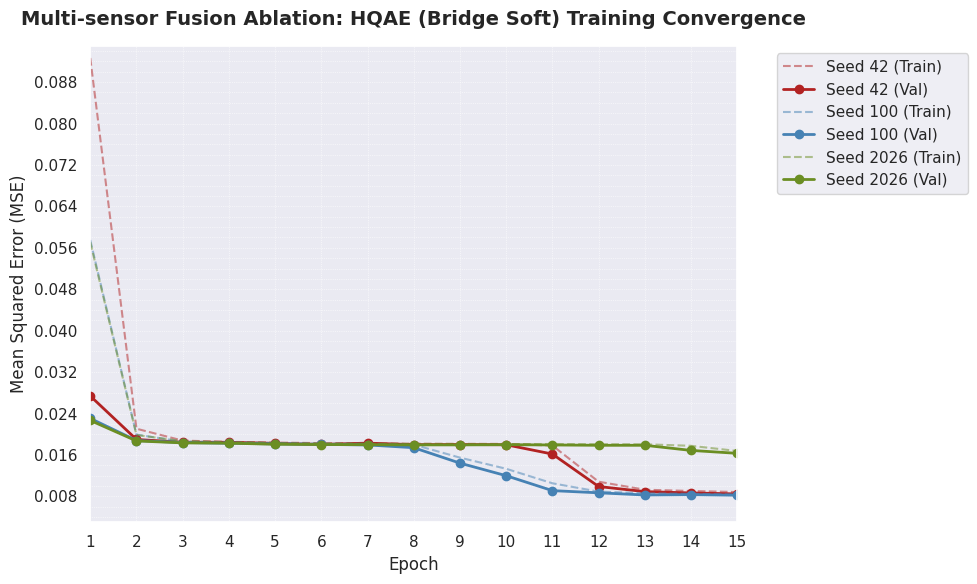

In [7]:
from src.utils.viz import plot_training_logs

DRIVE_LOGS = "/content/drive/MyDrive/spectra-cq-data/logs"
Y_LIMITS = (0.003, 0.095)

plot_training_logs(f"{DRIVE_LOGS}/phase4_bridge_soft.log", title="Multi-sensor Fusion Ablation: HQAE (Bridge Soft) Training Convergence", y_lim=Y_LIMITS)

## **Convergence Visualization (Validation MSE)**
Parses the logged terminal outputs saved during the execution loops to visualize epoch-by-epoch convergence across the 3 deterministic seeds. This identifies training instabilities, Barren Plateaus or gradient explosions.

Extracted Final MSEs (Average of final MSE of all 3 seeds):
CAE: 0.008340
HQAE (None): 0.008572
HQAE (Strong): 0.010787
HQAE (Bridge Hard): 0.012206
HQAE (Bridge Soft): 0.010999




/content/SPECTRA-CQ/src/utils/viz.py:104: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


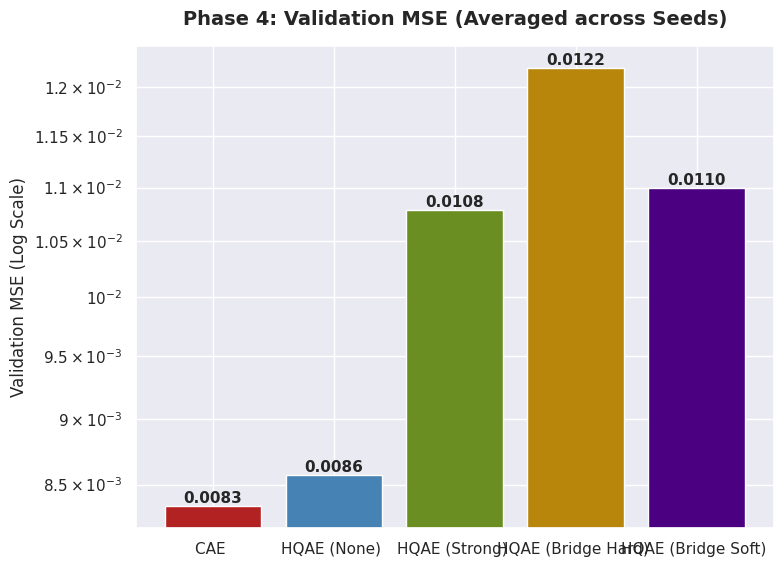

In [9]:
import re
from src.utils.viz import plot_ablation_results

# 1. Define the correct Google Drive path
DRIVE_LOGS = "/content/drive/MyDrive/spectra-cq-data/logs"

def extract_final_val_mse(log_path):
    """Extracts final validation MSE for all seeds from the execution log."""
    val_mses = []
    pattern = re.compile(r"Epoch 15/15 \| Train MSE: [\d.]+ \| Val MSE: ([\d.]+)")
    try:
        with open(log_path, "r") as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    val_mses.append(float(match.group(1)))
    except FileNotFoundError:
        print(f"Warning: Could not find {log_path}")
        return 0.0

    return sum(val_mses) / len(val_mses) if val_mses else 0.0

# 2. Inject the DRIVE_LOGS path into the dictionary
ablation_results = {
    "CAE \n": extract_final_val_mse(f"{DRIVE_LOGS}/phase4_cae.log"),
    "HQAE (None) \n": extract_final_val_mse(f"{DRIVE_LOGS}/phase4_none.log"),
    "HQAE (Strong) \n": extract_final_val_mse(f"{DRIVE_LOGS}/phase4_strong.log"),
    "HQAE (Bridge Hard) \n": extract_final_val_mse(f"{DRIVE_LOGS}/phase4_bridge_hard.log"),
    "HQAE (Bridge Soft) \n": extract_final_val_mse(f"{DRIVE_LOGS}/phase4_bridge_soft.log")
}

# 3. Print the raw numbers to the terminal to verify data extraction
print("Extracted Final MSEs (Average of final MSE of all 3 seeds):")
for model, mse in ablation_results.items():
    print(f"{model.strip()}: {mse:.6f}")

# 4. Generate the plot
print("\n")
plot_ablation_results(ablation_results, title="Phase 4: Validation MSE (Averaged across Seeds)")